In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmath
from scipy.stats import scoreatpercentile

## 1. Sistema no colisional esférico

In [81]:
# lectura de datos

data = pd.read_csv('Spherical_galaxy.csv',names=['x [kpc]','y [kpc]','z [kpc]','vx [km/s]','vy [km/s]','vz [km/s]'])

In [82]:
data

,x [kpc],y [kpc],z [kpc],vx [km/s],vy [km/s],vz [km/s]
0,0.025827,8.080713,-2.964450,-31.729433,58.914085,-38.310940
1,-1.275629,2.734614,0.053139,19.549257,30.629965,-6.506386
2,15.332361,4.224397,-15.025769,54.239281,-15.984748,21.306578
3,-5.702172,6.756396,-7.549031,-65.450752,25.626844,9.740432
4,16.160419,-5.821236,4.720833,-22.776388,65.532310,-1.868893
...,...,...,...,...,...,...
199995,-100.960793,-10.359862,73.410027,-6.398535,5.650262,16.406597
199996,-1.361795,6.515509,-1.782245,10.997408,-10.678014,-2.133975
199997,6.171734,0.643587,4.321414,40.191097,20.053066,-10.087251
199998,-5.110960,-14.092740,-0.920155,37.292534,19.064760,-2.376553


In [83]:
# conversión a coordenadas esféricas

data['r [kpc]'] = (data['x [kpc]']**2+data['y [kpc]']**2+data['z [kpc]']**2)**0.5
data['th [rad]'] = np.arccos(data['z [kpc]']/data['r [kpc]'])
data['ph [rad]'] = [cmath.polar(data['x [kpc]'][i]+1j*data['y [kpc]'][i])[1] for i in range(len(data))]
data

,x [kpc],y [kpc],z [kpc],vx [km/s],vy [km/s],vz [km/s],r [kpc],th [rad],ph [rad]
0,0.025827,8.080713,-2.964450,-31.729433,58.914085,-38.310940,8.607355,1.922405,1.567600
1,-1.275629,2.734614,0.053139,19.549257,30.629965,-6.506386,3.017974,1.553188,2.007266
2,15.332361,4.224397,-15.025769,54.239281,-15.984748,21.306578,21.879227,2.327818,0.268851
3,-5.702172,6.756396,-7.549031,-65.450752,25.626844,9.740432,11.625469,2.277529,2.271777
4,16.160419,-5.821236,4.720833,-22.776388,65.532310,-1.868893,17.813820,1.302582,-0.345746
...,...,...,...,...,...,...,...,...,...
199995,-100.960793,-10.359862,73.410027,-6.398535,5.650262,16.406597,125.257497,0.944593,-3.039338
199996,-1.361795,6.515509,-1.782245,10.997408,-10.678014,-2.133975,6.890772,1.832413,1.776838
199997,6.171734,0.643587,4.321414,40.191097,20.053066,-10.087251,7.561688,0.962478,0.103904
199998,-5.110960,-14.092740,-0.920155,37.292534,19.064760,-2.376553,15.019118,1.632100,-1.918710


In [84]:
# conversión de la velocidad a coordenadas esféricas

def vcart2vesf(theta,phi,vx,vy,vz):
    v = np.array([vx,vy,vz])
    A = np.array([[np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)],
                  [np.cos(theta)*np.cos(phi), np.cos(theta)*np.sin(phi), -np.sin(theta)],
                  [-np.sin(phi),np.cos(phi),0]])
    
    return A@v

vcart2vesf = np.vectorize(vcart2vesf)

In [85]:
# velocidad en coordenadas esféricas

V = np.array([vcart2vesf(data['th [rad]'][i],data['ph [rad]'][i],data['vx [km/s]'][i],data['vy [km/s]'][i],data['vz [km/s]'][i]) for i in range(len(data))])

In [86]:
data['vr [km/s]'] = V[:,0]
data['vth [km/s]'] = V[:,1]
data['vph [km/s]'] = V[:,2]

In [87]:
data

,x [kpc],y [kpc],z [kpc],vx [km/s],vy [km/s],vz [km/s],r [kpc],th [rad],ph [rad],vr [km/s],vth [km/s],vph [km/s]
0,0.025827,8.080713,-2.964450,-31.729433,58.914085,-38.310940,8.607355,1.922405,1.567600,68.408847,15.711558,31.917567
1,-1.275629,2.734614,0.053139,19.549257,30.629965,-6.506386,3.017974,1.553188,2.007266,19.376506,6.848620,-30.665106
2,15.332361,4.224397,-15.025769,54.239281,-15.984748,21.306578,21.879227,2.327818,0.268851,20.290598,-48.482717,-29.817777
3,-5.702172,6.756396,-7.549031,-65.450752,25.626844,9.740432,11.625469,2.277529,2.271777,40.671541,-47.536117,33.489630
4,16.160419,-5.821236,4.720833,-22.776388,65.532310,-1.868893,17.813820,1.302582,-0.345746,-42.572437,-9.762252,53.935390
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,-100.960793,-10.359862,73.410027,-6.398535,5.650262,16.406597,125.257497,0.944593,-3.039338,14.305523,-9.901185,-6.273890
199996,-1.361795,6.515509,-1.782245,10.997408,-10.678014,-2.133975,6.890772,1.832413,1.776838,-11.717939,5.346659,-8.580208
199997,6.171734,0.643587,4.321414,40.191097,20.053066,-10.087251,7.561688,0.962478,0.103904,28.745363,32.311169,15.776401
199998,-5.110960,-14.092740,-0.920155,37.292534,19.064760,-2.376553,15.019118,1.632100,-1.918710,-30.433781,4.249078,28.558300


In [88]:
# tensor de dispersión de velocidades de toda la distribución en coordenadas esféricas

sigma2esf = np.zeros((3,3))

for i in range(3):
    for j in range(3):
        sigma2esf[i,j] = np.mean(V[:,i]*V[:,j])-np.mean(V[:,i])*np.mean(V[:,j])

In [111]:
sigma2esf   # parece isotrópico

array([[1118.18447433,    3.13667106,   -1.74869997],
       [   3.13667106, 1119.87395258,    2.38316862],
       [  -1.74869997,    2.38316862, 1117.3641514 ]])

In [90]:
Vcart = np.array([data['vx [km/s]'].values,data['vy [km/s]'].values,data['vz [km/s]'].values])

In [112]:
# tensor de dispersión de velocidades de toda la distribución en coordenadas cartesianas

sigma2cart = np.zeros((3,3))

for i in range(3):
    for j in range(3):
        sigma2cart[i,j] = np.mean(Vcart[i]*Vcart[j])-np.mean(Vcart[i])*np.mean(Vcart[j])

sigma2cart   # parece isotrópico x2

array([[ 1.12119804e+03, -2.33955972e+00, -2.36914191e+00],
       [-2.33955972e+00,  1.11176534e+03, -2.45999930e-01],
       [-2.36914191e+00, -2.45999930e-01,  1.12246852e+03]])

In [113]:
# parámetro de anisotropía para toda la distribución

betaT = 1-(np.mean(V[:,1]**2)+np.mean(V[:,2]**2))/(2*np.mean(V[:,0]**2))
betaT

-0.0003893541394843769

In [134]:
# parámetro de anisotropía dependiente de r

npoints = 17
beta_data = np.zeros(npoints-1)
dr = (data['r [kpc]'].max()-data['r [kpc]'].min())/(npoints-1)
rs = np.array([data['r [kpc]'].min() + i*dr for i in range(npoints)])
rsmean = (rs[:-1]+rs[1:])/2

for i in range(npoints-1):
    mask = (data['r [kpc]'] >= rs[i]) & (data['r [kpc]'] < rs[i+1])
    dummydf = data[mask]
    vr2m = np.mean(dummydf['vr [km/s]']**2)
    vt2m = np.mean(dummydf['vth [km/s]']**2)
    vp2m = np.mean(dummydf['vph [km/s]']**2)

    beta_data[i] = 1-(vt2m+vp2m)/(2*vr2m)

In [141]:
# bootstrapping (no sé si está bien hecho, pero ajá)

ntries = 1000

low_b = np.zeros_like(beta_data)
high_b = np.zeros_like(beta_data)

beta_dum = np.zeros(ntries)

for i in range(npoints-1):
    mask = (data['r [kpc]'] >= rs[i]) & (data['r [kpc]'] < rs[i+1])
    dummydf = data[mask]
    vr2 = (dummydf['vr [km/s]']**2).values
    vt2 = (dummydf['vth [km/s]']**2).values
    vp2 = (dummydf['vph [km/s]']**2).values

    for j in range(ntries):
        vr2m = np.mean(np.random.choice(vr2,npoints-1))
        vt2m = np.mean(np.random.choice(vt2,npoints-1))
        vp2m = np.mean(np.random.choice(vp2,npoints-1))
        beta_dum[j] = 1-(vt2m+vp2m)/(2*vr2m)

    low_b[i] = scoreatpercentile(beta_dum,2.5)
    high_b[i] = scoreatpercentile(beta_dum,97.5)

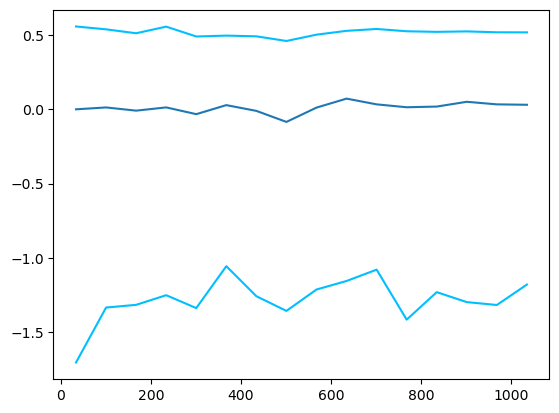

In [142]:
plt.plot(rsmean,beta_data)
plt.plot(rsmean,low_b,'deepskyblue')
plt.plot(rsmean,high_b,'deepskyblue')


Diría que sí es isotrópico, pues dentro de un intervalo de confianza de 95 % para el parámetro de anisotropía $\beta$ está contenido $\beta=0$